In [12]:
from sklearn.datasets import load_digits #ML
import matplotlib.pyplot as plt #plotting

digits = load_digits() #image dataset

print(digits.data.shape) #1797 image each has 64 brightness values

(1797, 64)


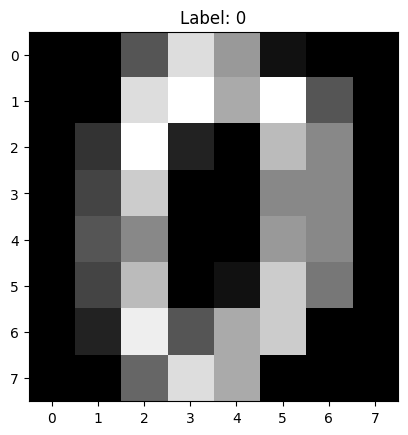

In [13]:
plt.imshow(digits.images[0], cmap="gray") #display first image
plt.title(f"Label: {digits.target[0]}")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
import torch #library to build neural networks 

X = digits.data #images
y = digits.target #number shown in the image

X = X / 16.0 #makes the values of the pixels smaller (between 0 - 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# A tensor is a container of numbers

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print("In this code, we prepared the training and testing data for the neural network. We split the dataset into data the model will learn from and data we will use to test it later. Then we converted both the images and labels into PyTorch tensors, because PyTorch models require tensors for training and testing.")

torch.Size([1437, 64])
torch.Size([1437])
torch.Size([360, 64])
torch.Size([360])
In this code, we prepared the training and testing data for the neural network. We split the dataset into data the model will learn from and data we will use to test it later. Then we converted both the images and labels into PyTorch tensors, because PyTorch models require tensors for training and testing.


In [15]:
import torch.nn as nn #this modules contains tools for building neural networks
#Input Layer
#(64 pixel values) (64 nodes)
#        ↓
#Hidden Layer
#(32 neurons + ReLU activation)
#        ↓
#Output Layer
#(10 neurons)

model = nn.Sequential( #Take the data and pass it through these layers in order.
    nn.Linear(64, 32), #each neuron of the 32 recieve the same image aka the 64 pixels and tries to find a specific patter. It's linear because all neurons in the first layer are based on a linear equation. Also, this is the case in almost all neural networks.
    nn.ReLU(), #not a neuron layer, but an activation function. If number is negative → 0, If number is positive → keep it. A negative value means the pattern the neuron was looking for wasn't there.
    nn.Linear(32, 10) #gives us 10 scores, and we choose the highest score (our output).
)

print(model)

Sequential(
  (0): Linear(in_features=64, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=10, bias=True)
)


In [20]:
loss_fn = nn.CrossEntropyLoss() #CrossEntropyLoss is the standard loss function for classification. A loss function is a function that tells the model how wrong it was.

optimizer = torch.optim.Adam( #an optimizer is the mechanic that adjusts the neural network. Adam is a smart algo for updating weights 
    model.parameters(), #means all the weights and biases inside the neural network.
    lr=0.01 #Even if the loss is large, the learning rate controls how big the weight update is. For each update, move the weights by 1% of the calculated gradient step.
)
#Positive gradient → decrease the weight
#Negative gradient → increase the weight

In [18]:
epochs = 100
#repeat training 100 times
for epoch in range(epochs):
    predictions = model(X_train) #model makes predictions
    
    loss = loss_fn(predictions, y_train) #checks how wrong it was
    
    optimizer.zero_grad() #clear gradient
    loss.backward() #backpropagation
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 1.6730
Epoch 20, Loss: 0.7980
Epoch 30, Loss: 0.3711
Epoch 40, Loss: 0.2228
Epoch 50, Loss: 0.1537
Epoch 60, Loss: 0.1186
Epoch 70, Loss: 0.0969
Epoch 80, Loss: 0.0818
Epoch 90, Loss: 0.0704
Epoch 100, Loss: 0.0614


In [19]:
#Training Loop Structure:
#Forward pass
#Compute loss
#Backpropagation
#Update weights
#Repeat

In [23]:
#testing phase
with torch.no_grad():
    predictions = model(X_test)
    predicted_labels = predictions.argmax(dim=1) #choose the highest score of the predictions made for each image
    accuracy = (predicted_labels == y_test).float().mean() #find the accuracy for the whole model

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9639


In [24]:
#Basic Machine Learning pipeline
#Load Data
#    ↓
#Prepare Data
#    ↓
#Build Neural Network
#    ↓
#Define Loss & Optimizer
#    ↓
#Train
#    ↓
#Evaluate

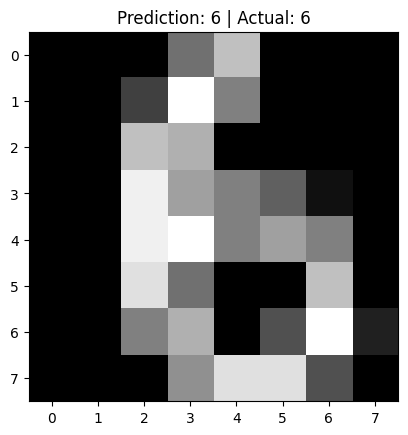

In [25]:
import matplotlib.pyplot as plt

index = 0

plt.imshow(X_test[index].reshape(8,8), cmap="gray")
plt.title(
    f"Prediction: {predicted_labels[index].item()} | Actual: {y_test[index].item()}"
)
plt.show()

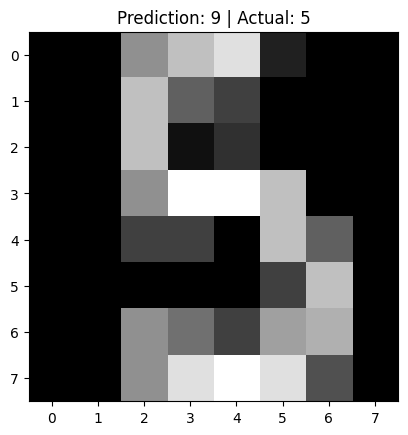

In [30]:
for i in range(len(X_test)):
    if predicted_labels[i] != y_test[i]:

        plt.imshow(X_test[i].reshape(8,8), cmap="gray")
        plt.title(
            f"Prediction: {predicted_labels[i].item()} | Actual: {y_test[i].item()}"
        )
        plt.show()

        break

In [27]:
torch.save(model.state_dict(), "digit_model.pth")

In [28]:
def predict_digit(index):
    with torch.no_grad(): #basically we are saying that we are only making predictions right now so don't use gradients. 
        output = model(X_test[index])
        prediction = output.argmax().item()

    print("Prediction:", prediction)
    print("Actual:", y_test[index].item())

In [29]:
predict_digit(15)

Prediction: 2
Actual: 2
